## **Load Libraries**

In [172]:
import pandas as pd
pd.options.mode.chained_assignment = None

import matplotlib.pyplot as plt
import seaborn as sns

## **Load Data**

In [173]:
sales = pd.read_csv("/content/drive/MyDrive/CIND 820/Milestone 2/amazon.csv")

## **Preview Data**

In [174]:
# Number of observations and features
sales.shape

(1465, 16)

In [175]:
sales.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [176]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## **Data Preparation**

In [177]:
# Remove characters from numerical columns and convert to float data type
sales['actual_price'] = sales['actual_price'].str.replace('₹', '', regex=False)
sales['actual_price'] = sales['actual_price'].str.replace(',', '', regex=False)
sales['actual_price'] = sales['actual_price'].astype(float)

sales['discounted_price'] = sales['discounted_price'].str.replace('₹', '', regex=False)
sales['discounted_price'] = sales['discounted_price'].str.replace(',', '', regex=False)
sales['discounted_price'] = sales['discounted_price'].astype(float)

sales['discount_percentage'] = sales['discount_percentage'].str.replace('%', '', regex=False)
sales['discount_percentage'] = sales['discount_percentage'].astype(float)

sales['rating_count'] = sales['rating_count'].str.replace(',', '', regex=False)
sales['rating_count'] = sales['rating_count'].astype(float)

In [178]:
sales.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## **Summary of Quantitative Features**

In [179]:
sales[["actual_price", "discounted_price", "discount_percentage", "rating_count"]].describe()

,actual_price,discounted_price,discount_percentage,rating_count
count,1465.000000,1465.000000,1465.000000,1463.000000
mean,5444.990635,3125.310874,47.691468,18295.541353
std,10874.826864,6944.304394,21.635905,42753.864952
min,39.000000,39.000000,0.000000,2.000000
25%,800.000000,325.000000,32.000000,1186.000000
50%,1650.000000,799.000000,50.000000,5179.000000
75%,4295.000000,1999.000000,63.000000,17336.500000
max,139900.000000,77990.000000,94.000000,426973.000000


## **Summary of Qualitative Features**

In [180]:
# Frequency of product category
sales["category"].value_counts()

,count
category,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,233
Electronics|WearableTechnology|SmartWatches,76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,68
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",63
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",52
...,...
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers,1
"Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories",1
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|StandMixers,1


In [181]:
# Number of categories with fewer than 20 products
(sales["category"].value_counts() < 30).sum()

np.int64(205)

In [182]:
# Number of categories with more than 20 products
(sales["category"].value_counts() >= 30).sum()

np.int64(6)

In [183]:
# Frequency of rating
sales["rating"].value_counts()

,count
rating,
4.1,244
4.3,230
4.2,228
4.0,129
3.9,123
4.4,123
3.8,86
4.5,75
4,52


## **Compressing the Data**

In [184]:
# Remove rows corresponding to categories with low frequencies
category_counts = sales["category"].value_counts()
relevant_categories = category_counts[category_counts >= 30].index
sales_compressed_1 = sales[sales["category"].isin(relevant_categories)]

# Remove rows corresponding to ratings with low frequencies
rating_counts = sales_compressed_1["rating"].value_counts()
relevant_ratings = rating_counts[rating_counts >= 30].index
sales_compressed_2 = sales_compressed_1[sales_compressed_1["rating"].isin(relevant_ratings)]

In [185]:
sales_compressed_2["category"].value_counts()

,count
category,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,188
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,65
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",59
Electronics|WearableTechnology|SmartWatches,59
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",32
"Electronics|HomeTheater,TV&Video|Accessories|RemoteControls",18


In [186]:
sales_compressed_2["rating"].value_counts()

,count
rating,
4.1,102
4.2,101
4.3,94
4.0,70
3.9,54


## **Average by Category**

In [187]:
sales_compressed_2.groupby(['category'])[["actual_price", "discounted_price", "discount_percentage", "rating_count"]].mean()

,actual_price,discounted_price,discount_percentage,rating_count
category,,,,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,824.469787,305.710745,60.579787,15163.984043
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",2427.437500,932.250000,53.062500,111749.125000
"Electronics|HomeTheater,TV&Video|Accessories|RemoteControls",1126.833333,386.666667,57.277778,848.166667
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",38955.169492,24383.966102,37.627119,12739.000000
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,20613.138462,15773.938462,23.092308,37995.200000
Electronics|WearableTechnology|SmartWatches,9181.762712,2429.423729,69.864407,26073.508475


## **Average by Rating**

In [188]:
sales_compressed_2.groupby(['rating'])[["actual_price", "discounted_price", "discount_percentage", "rating_count"]].mean()

,actual_price,discounted_price,discount_percentage,rating_count
rating,,,,
3.9,5900.542963,3417.106296,61.111111,15387.814815
4.0,4193.957143,2394.284143,54.628571,16884.257143
4.1,9970.901961,6498.057745,46.019608,54020.588235
4.2,11581.019802,6349.376238,54.495050,26996.485149
4.3,17382.691489,11120.735106,49.351064,10128.819149


## **Median Rating by Category**

In [189]:
sales_compressed_2['rating'] = sales_compressed_2['rating'].astype(float)
sales_compressed_2.groupby(['category'])["rating"].median()

,rating
category,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,4.1
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",4.1
"Electronics|HomeTheater,TV&Video|Accessories|RemoteControls",4.0
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",4.2
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,4.1
Electronics|WearableTechnology|SmartWatches,4.1


## **Distributions of Quantitative Features**


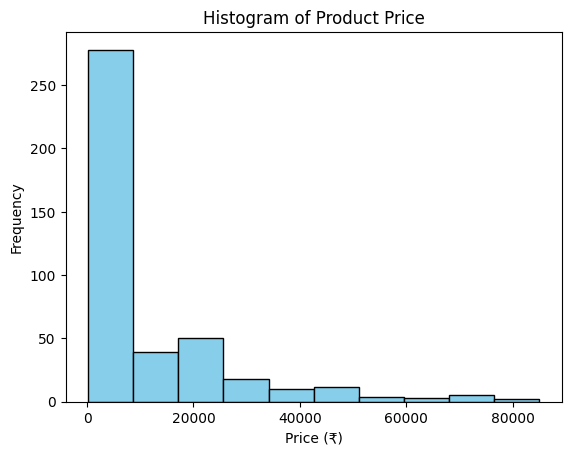

In [190]:
plt.hist(sales_compressed_2['actual_price'], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Product Price")
plt.xlabel("Price (₹)")
plt.ylabel("Frequency")
plt.show()

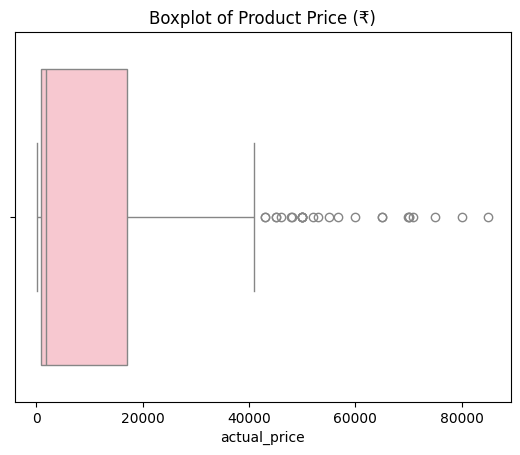

In [191]:
sns.boxplot(x='actual_price', data=sales_compressed_2, color="pink")
plt.title("Boxplot of Product Price (₹)")
plt.show()

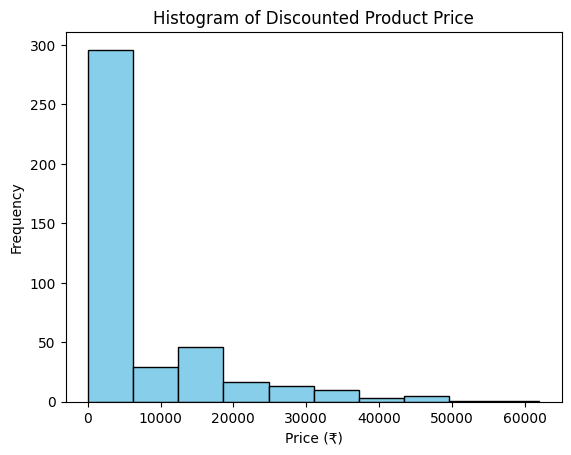

In [192]:
plt.hist(sales_compressed_2['discounted_price'], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Discounted Product Price")
plt.xlabel("Price (₹)")
plt.ylabel("Frequency")
plt.show()

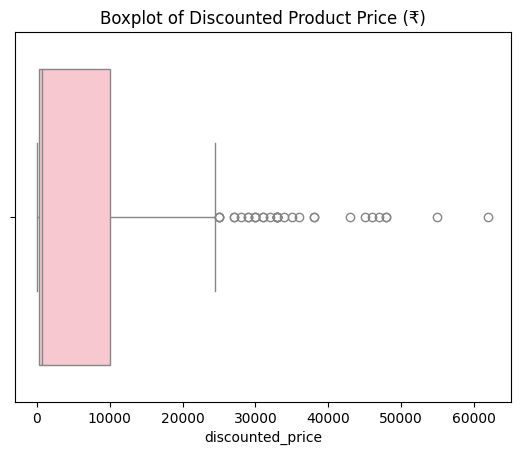

In [193]:
sns.boxplot(x='discounted_price', data=sales_compressed_2, color="pink")
plt.title("Boxplot of Discounted Product Price (₹)")
plt.show()

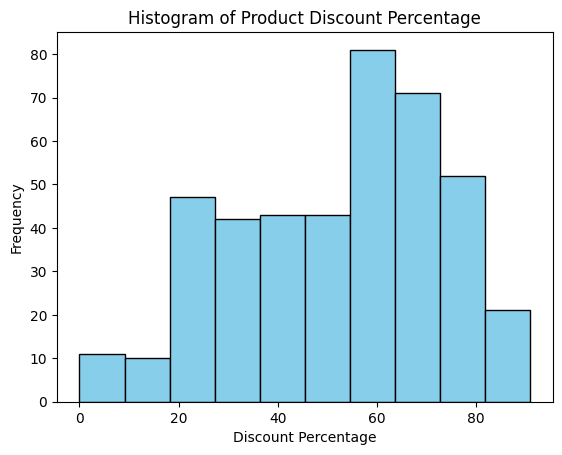

In [194]:
plt.hist(sales_compressed_2['discount_percentage'], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Product Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.show()

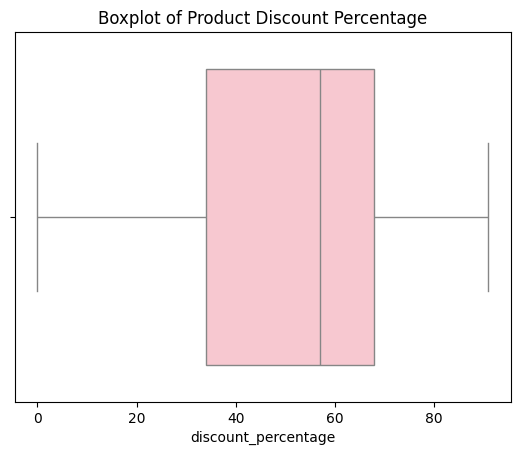

In [195]:
sns.boxplot(x='discount_percentage', data=sales_compressed_2, color="pink")
plt.title("Boxplot of Product Discount Percentage")
plt.show()

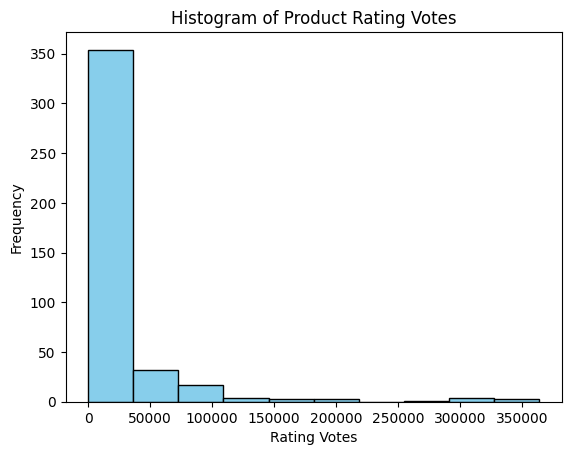

In [196]:
plt.hist(sales_compressed_2['rating_count'], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Product Rating Votes")
plt.xlabel("Rating Votes")
plt.ylabel("Frequency")
plt.show()

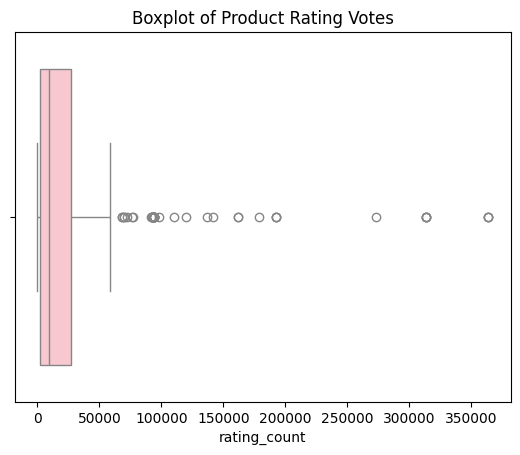

In [197]:
sns.boxplot(x='rating_count', data=sales_compressed_2, color="pink")
plt.title("Boxplot of Product Rating Votes")
plt.show()

## **Distributions by Category**

/tmp/ipykernel_4588/4209899008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='actual_price', y='category', data=sales_compressed_2, palette='pastel')


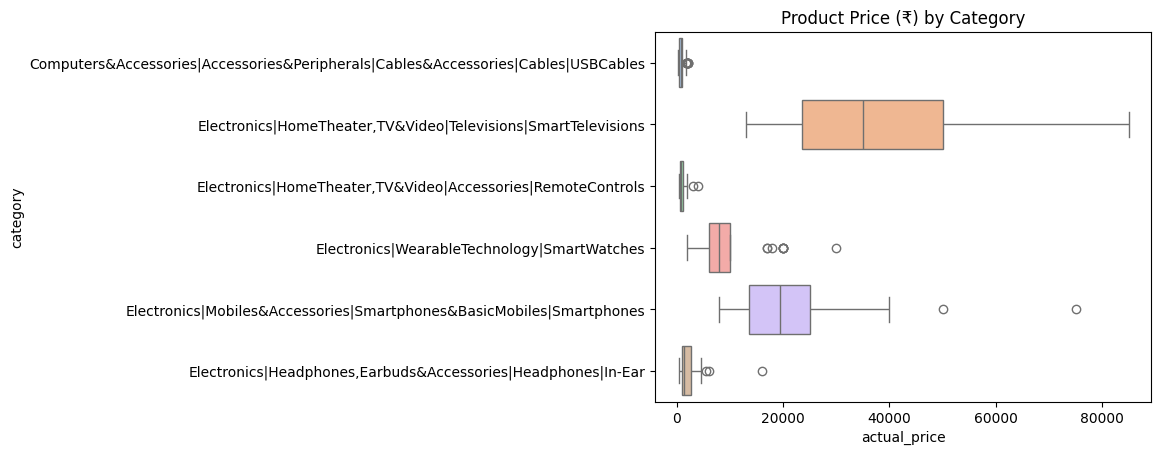

In [198]:
# Price by category
sns.boxplot(x='actual_price', y='category', data=sales_compressed_2, palette='pastel')
plt.title("Product Price (₹) by Category")
plt.show()

/tmp/ipykernel_4588/3474349390.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='discount_percentage', y='category', data=sales_compressed_2, palette='pastel')


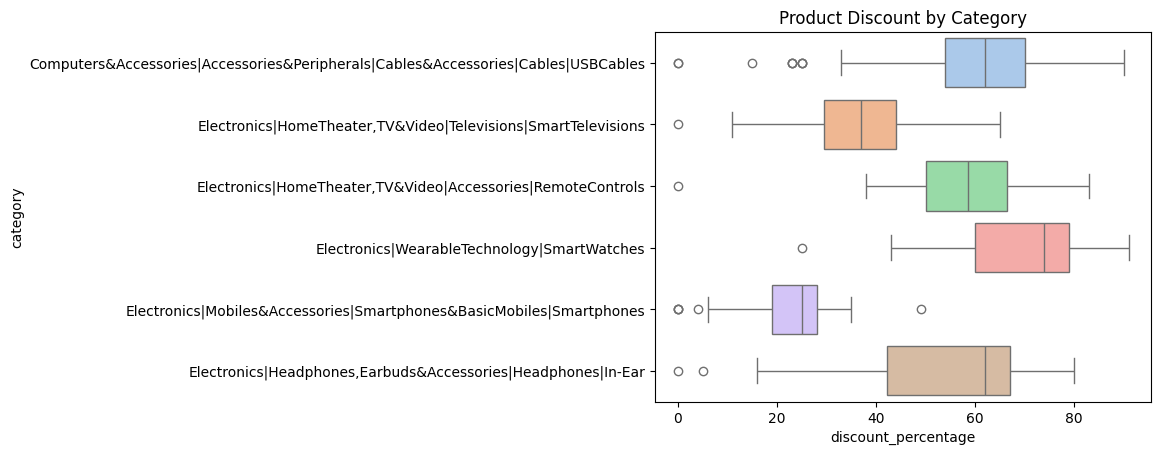

In [199]:
# Price by category
sns.boxplot(x='discount_percentage', y='category', data=sales_compressed_2, palette='pastel')
plt.title("Product Discount by Category")
plt.show()

## **Distributions of Qualitative Features**


/tmp/ipykernel_4588/245508491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=sales_compressed_2, palette='coolwarm')


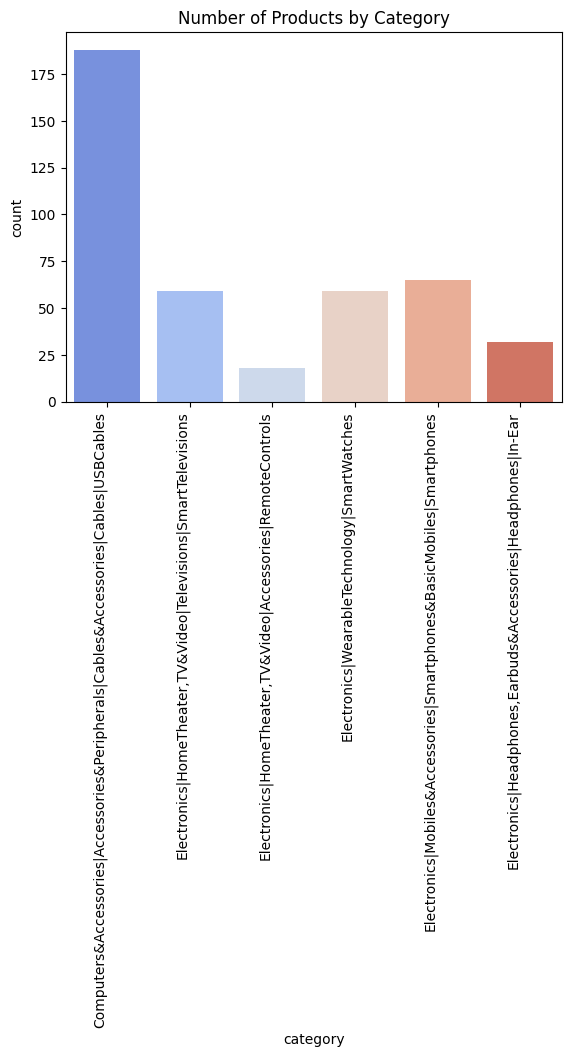

In [200]:
# Product category
sns.countplot(x='category', data=sales_compressed_2, palette='coolwarm')
plt.title("Number of Products by Category")
plt.xticks(rotation=90, ha="right")
plt.show()

/tmp/ipykernel_4588/3882417455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=sales_compressed_2, palette='coolwarm')


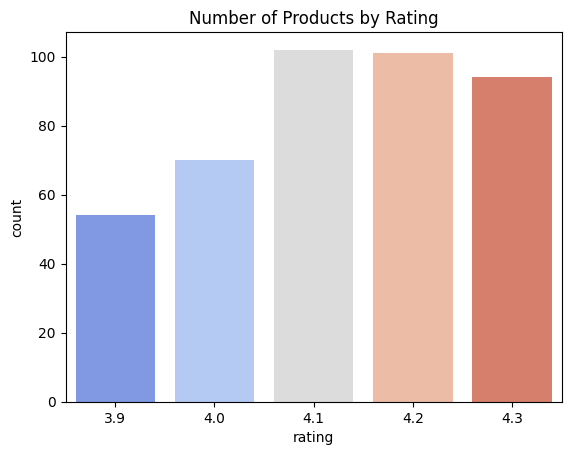

In [201]:
# Product rating
sns.countplot(x='rating', data=sales_compressed_2, palette='coolwarm')
plt.title("Number of Products by Rating")
plt.show()

## **Detection of Linear Relationships**

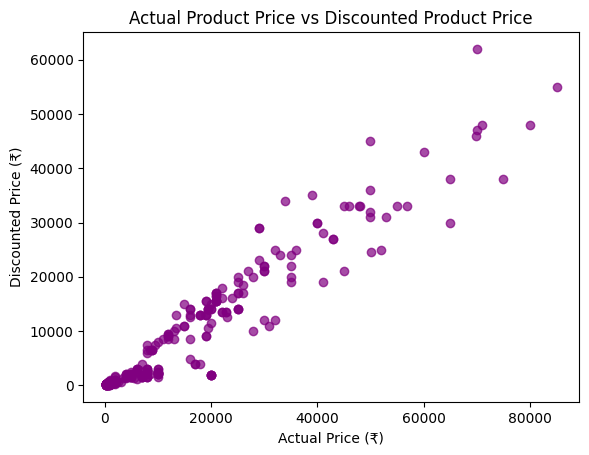

In [202]:
# Actual price vs discounted price
plt.scatter(sales_compressed_2['actual_price'], sales_compressed_2['discounted_price'], alpha=0.7, color='purple')
plt.title("Actual Product Price vs Discounted Product Price")
plt.xlabel("Actual Price (₹)")
plt.ylabel("Discounted Price (₹)")
plt.show()

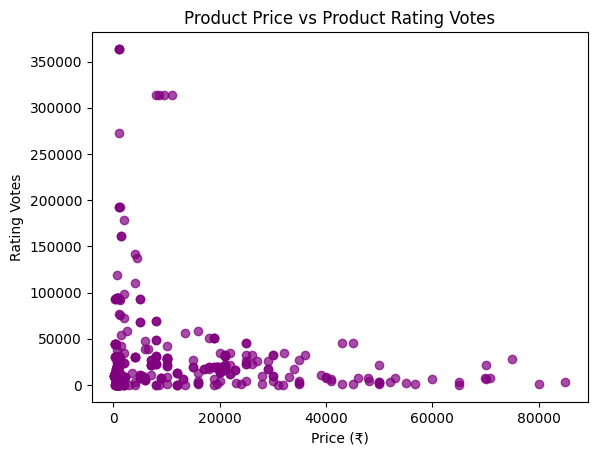

In [203]:
# Actual price vs rating votes
plt.scatter(sales_compressed_2['actual_price'], sales_compressed_2['rating_count'], alpha=0.7, color='purple')
plt.title("Product Price vs Product Rating Votes")
plt.xlabel("Price (₹)")
plt.ylabel("Rating Votes")
plt.show()

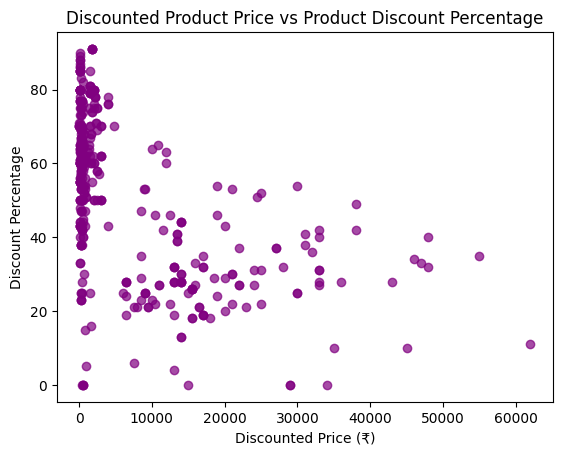

In [204]:
# Discounted price vs discount percentage
plt.scatter(sales_compressed_2['discounted_price'], sales_compressed_2['discount_percentage'], alpha=0.7, color='purple')
plt.title("Discounted Product Price vs Product Discount Percentage")
plt.xlabel("Discounted Price (₹)")
plt.ylabel("Discount Percentage")
plt.show()

In [205]:
sales_compressed_2[["actual_price", "discounted_price", "discount_percentage", "rating_count"]].corr()

,actual_price,discounted_price,discount_percentage,rating_count
actual_price,1.000000,0.962910,-0.415841,-0.100234
discounted_price,0.962910,1.000000,-0.554204,-0.084120
discount_percentage,-0.415841,-0.554204,1.000000,-0.080742
rating_count,-0.100234,-0.084120,-0.080742,1.000000
